<a href="https://colab.research.google.com/github/limerya/FINAL_bigdata/blob/main/bigdata_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data preprocessing

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import pandas as pd
import numpy as np

RAW_DIR = '/content/drive/MyDrive/gdelt_data/raw'
CLEAN_DIR = '/content/drive/MyDrive/gdelt_data/cleaned'
PROCESSED_DIR = '/content/drive/MyDrive/gdelt_data/processed'

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

files = sorted(glob.glob(f'{RAW_DIR}/*.parquet'))
print(f"Found {len(files)} files")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 50 files


In [10]:
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f"Total rows loaded: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nSQLDATE range: {df['SQLDATE'].min()} to {df['SQLDATE'].max()}")
print(f"DATEADDED range: {df['DATEADDED'].min()} to {df['DATEADDED'].max()}")

Total rows loaded: 64,603
Memory usage: 112.9 MB

SQLDATE range: 20151004 to 20251001
DATEADDED range: 20251001000000 to 20251001121500


In [11]:
n_before = len(df)

# Parse dates properly
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce')
df['date_added'] = pd.to_datetime(df['DATEADDED'].astype(str).str[:8], format='%Y%m%d', errors='coerce')

# Drop rows with no event date
df = df.dropna(subset=['date'])

# Cross-file deduplication on GLOBALEVENTID
df = df.drop_duplicates(subset=['GLOBALEVENTID'])

# Drop events with no action country (can't be used for geographic clustering)
df = df[df['ActionGeo_CountryCode'].notna() & (df['ActionGeo_CountryCode'] != '')]

# Cast numerics safely
for col in ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources', 'NumArticles',
            'QuadClass', 'EventCode', 'EventRootCode']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Clip Goldstein outliers
df = df[df['GoldsteinScale'].between(-10, 10) | df['GoldsteinScale'].isna()]

# Time bucket helpers — pre-compute so feature engineering is one-liner
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.to_period('M').dt.start_time
df['week']  = df['date'].dt.to_period('W').dt.start_time

print(f"Rows before: {n_before:,}")
print(f"Rows after:  {len(df):,}")
print(f"Dropped:     {n_before - len(df):,} ({(n_before-len(df))/n_before*100:.1f}%)")

Rows before: 64,603
Rows after:  62,611
Dropped row w/ no date:     1,992 (3.1%)


In [1]:
n_before = len(df)
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce')
df['date_added'] = pd.to_datetime(df['DATEADDED'].astype(str).str[:8], format='%Y%m%d', errors='coerce')

df = df.dropna(subset=['date'])
print(f"After date drop:        {len(df):,}")

df = df.drop_duplicates(subset=['GLOBALEVENTID'])
print(f"After dedup:            {len(df):,}")

df = df[df['ActionGeo_CountryCode'].notna() & (df['ActionGeo_CountryCode'] != '')]
print(f"After country drop:     {len(df):,}")

# ... etc.

NameError: name 'df' is not defined

In [ ]:
print("SQLDATE year distribution:")
print(df['Year'].value_counts().sort_index())

print("\nDATEADDED year distribution:")
print(df['date_added'].dt.year.value_counts().sort_index())

print(f"\nGap between event date and ingestion date:")
gap = (df['date_added'] - df['date']).dt.days
print(gap.describe())

In [ ]:
country_week_coverage = df.groupby('ActionGeo_CountryCode')['week'].nunique().sort_values(ascending=False)
print("Country-week coverage (how many distinct weeks each country appears in):")
print(country_week_coverage.describe())
print(f"\nCountries appearing in ≥10 weeks: {(country_week_coverage >= 10).sum()}")
print(f"Countries appearing in ≥4 weeks:  {(country_week_coverage >= 4).sum()}")

In [ ]:
corr_full = df[['GoldsteinScale', 'AvgTone']].dropna().corr().iloc[0, 1]
print(f"Goldstein–AvgTone correlation (full data): {corr_full:.3f}")

In [12]:
print("=== Date coverage ===")
print(f"Event dates: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique days: {df['date'].dt.date.nunique()}")
print(f"Span: {(df['date'].max() - df['date'].min()).days} days\n")

print("=== Top 15 countries by event count ===")
print(df['ActionGeo_CountryCode'].value_counts().head(15), "\n")

print("=== QuadClass distribution ===")
# 1=Verbal Coop, 2=Material Coop, 3=Verbal Conflict, 4=Material Conflict
quad_labels = {1: 'Verbal Coop', 2: 'Material Coop', 3: 'Verbal Conflict', 4: 'Material Conflict'}
qc = df['QuadClass'].value_counts().sort_index()
for k, v in qc.items():
    print(f"  {int(k)} {quad_labels.get(int(k), '?'):20s}: {v:>8,}")

print(f"\n=== Goldstein stats ===")
print(df['GoldsteinScale'].describe())

=== Date coverage ===
Event dates: 2015-10-04 → 2025-10-01
Unique days: 6
Span: 3650 days

=== Top 15 countries by event count ===
ActionGeo_CountryCode
US    21998
IS     3787
IN     3067
UK     3060
AS     1928
NI     1601
CH     1584
CA     1432
RS     1100
PK     1077
UP     1031
EI      720
SF      662
FR      567
GM      553
Name: count, dtype: int64 

=== QuadClass distribution ===
  1 Verbal Coop         :   39,025
  2 Material Coop       :    7,493
  3 Verbal Conflict     :    7,997
  4 Material Conflict   :    8,096

=== Goldstein stats ===
count    62611.000000
mean         0.741616
std          4.573017
min        -10.000000
25%         -2.000000
50%          1.900000
75%          3.400000
max         10.000000
Name: GoldsteinScale, dtype: float64


In [13]:
out_path = f'{CLEAN_DIR}/events_cleaned.parquet'
df.to_parquet(out_path, compression='snappy', index=False)
print(f"Saved: {out_path}")
print(f"Size: {os.path.getsize(out_path) / 1e6:.1f} MB")
print(f"Rows: {len(df):,}")

Saved: /content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet
Size: 4.5 MB
Rows: 62,611


EDA

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

CLEAN_PATH = '/content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet'
df = pd.read_parquet(CLEAN_PATH)

print(f"Loaded {len(df):,} events")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Countries: {df['ActionGeo_CountryCode'].nunique()}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 62,611 events
Date range: 2015-10-04 → 2025-10-01
Countries: 213
Memory: 111.4 MB


In [15]:
# Missing value report for the columns that matter for your research
key_cols = [
    'GLOBALEVENTID', 'date', 'Actor1CountryCode', 'Actor2CountryCode',
    'Actor1Type1Code', 'Actor2Type1Code', 'IsRootEvent', 'EventCode',
    'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions',
    'NumSources', 'NumArticles', 'AvgTone', 'ActionGeo_CountryCode',
    'ActionGeo_Lat', 'ActionGeo_Long'
]

missing = pd.DataFrame({
    'n_missing': df[key_cols].isna().sum(),
    'pct_missing': (df[key_cols].isna().mean() * 100).round(2),
    'n_unique': df[key_cols].nunique(),
    'dtype': df[key_cols].dtypes.astype(str)
}).sort_values('pct_missing', ascending=False)

print(missing)

                       n_missing  pct_missing  n_unique           dtype
Actor2Type1Code            42048        67.16        32          object
Actor2CountryCode          35406        56.55       193          object
Actor1Type1Code            35349        56.46        31          object
Actor1CountryCode          27516        43.95       201          object
ActionGeo_Lat                 25         0.04      3882         float64
ActionGeo_Long                 9         0.01      4043         float64
date                           0         0.00         6  datetime64[ns]
GLOBALEVENTID                  0         0.00     62611           int64
IsRootEvent                    0         0.00         2           int64
EventCode                      0         0.00       189           int64
QuadClass                      0         0.00         4           int64
EventRootCode                  0         0.00        20           int64
GoldsteinScale                 0         0.00        42         

Mean events/day: 10435
Median events/day: 308
Max events/day: 61,254 on 2025-10-01
Min events/day: 13 on 2015-10-04


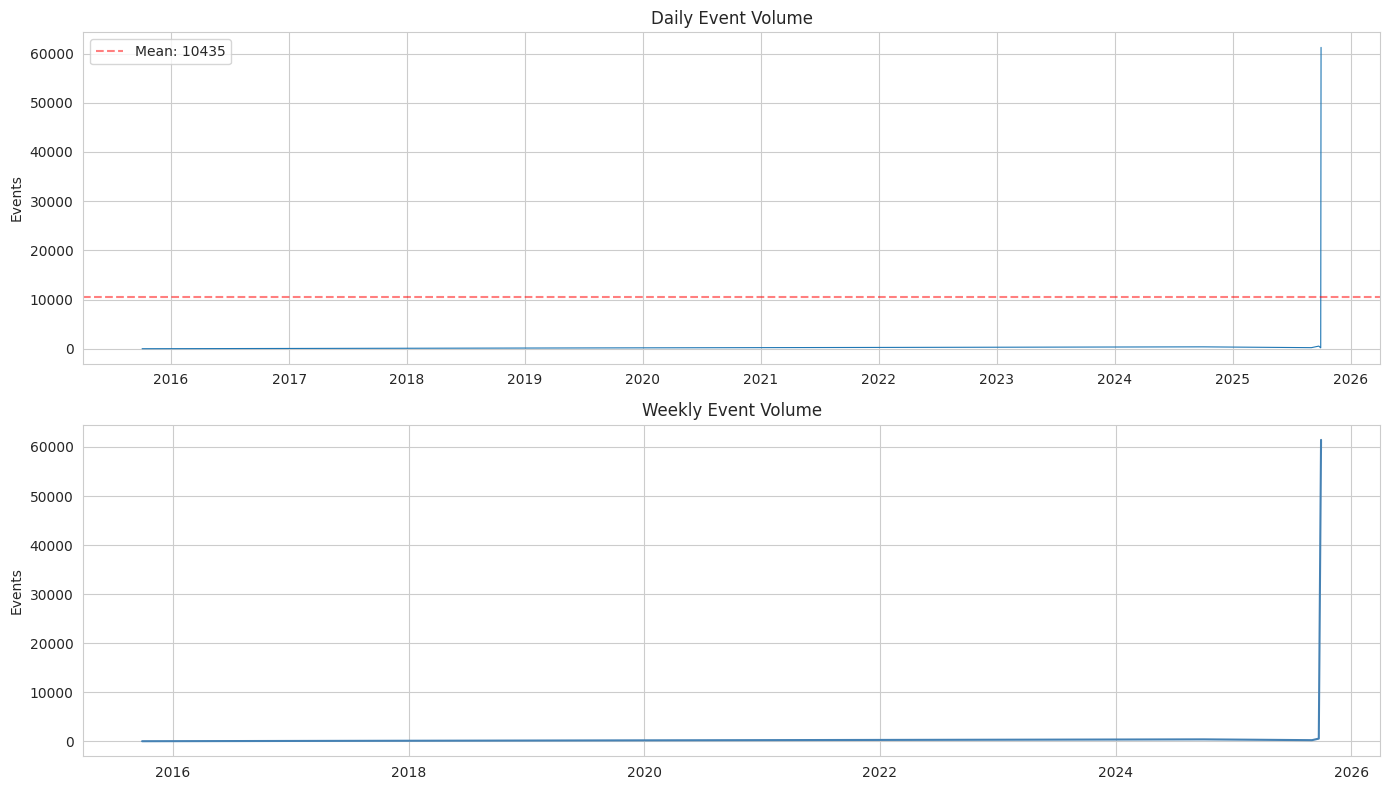

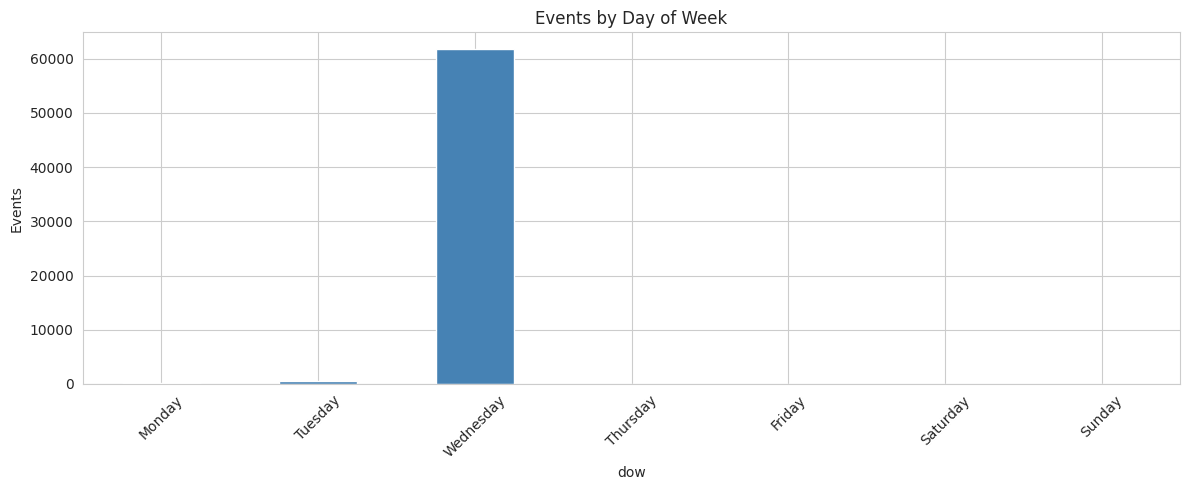

In [16]:
# Daily event volume
daily = df.groupby(df['date'].dt.date).size()
print(f"Mean events/day: {daily.mean():.0f}")
print(f"Median events/day: {daily.median():.0f}")
print(f"Max events/day: {daily.max():,} on {daily.idxmax()}")
print(f"Min events/day: {daily.min()} on {daily.idxmin()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily volume
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title('Daily Event Volume')
axes[0].set_ylabel('Events')
axes[0].axhline(daily.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {daily.mean():.0f}')
axes[0].legend()

# Weekly volume (smoother trend)
weekly = df.groupby('week').size()
axes[1].plot(weekly.index, weekly.values, linewidth=1.5, color='steelblue')
axes[1].set_title('Weekly Event Volume')
axes[1].set_ylabel('Events')

plt.tight_layout()
plt.show()

# Day-of-week pattern (GDELT often has weekend dips)
df['dow'] = df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('dow').size().reindex(dow_order).plot(kind='bar', color='steelblue')
plt.title('Events by Day of Week')
plt.ylabel('Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total countries with events: 213
Countries with ≥100 events: 78
Countries with ≥30 events:  127
Countries with <10 events:  42


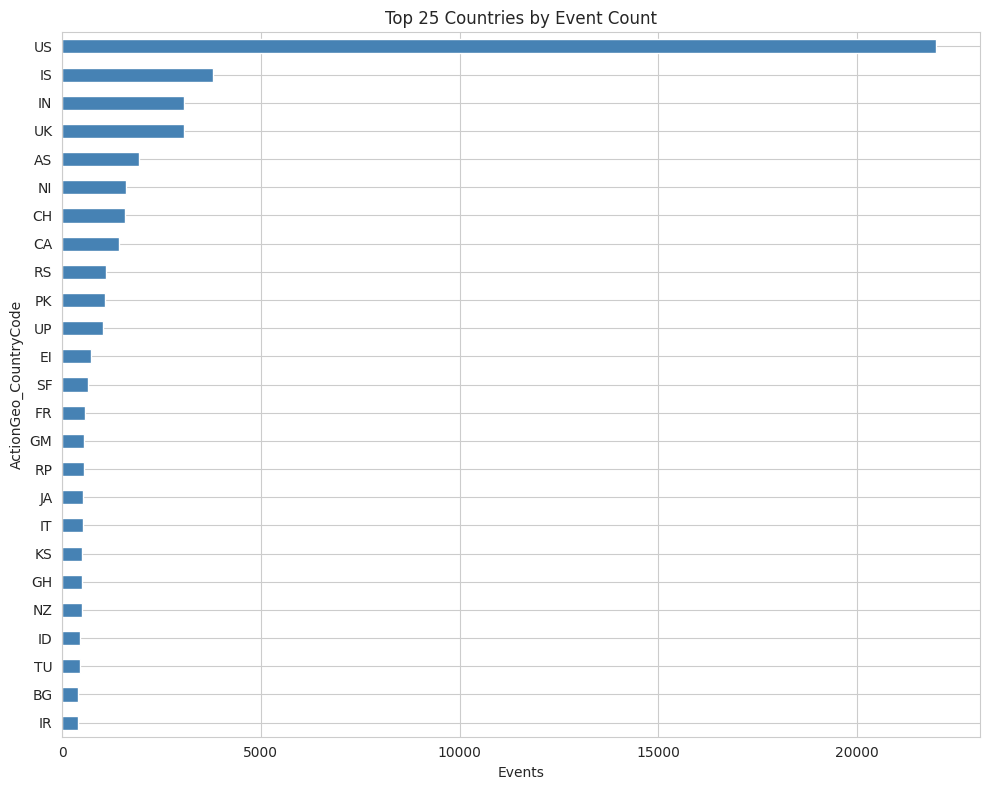


Top 10 countries account for 64.9% of all events


In [17]:
# Country event counts
country_counts = df['ActionGeo_CountryCode'].value_counts()

print(f"Total countries with events: {len(country_counts)}")
print(f"Countries with ≥100 events: {(country_counts >= 100).sum()}")
print(f"Countries with ≥30 events:  {(country_counts >= 30).sum()}")
print(f"Countries with <10 events:  {(country_counts < 10).sum()}")

# Top 25 countries
fig, ax = plt.subplots(figsize=(10, 8))
country_counts.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 25 Countries by Event Count')
ax.set_xlabel('Events')
plt.tight_layout()
plt.show()

# Coverage concentration
top10_share = country_counts.head(10).sum() / country_counts.sum() * 100
print(f"\nTop 10 countries account for {top10_share:.1f}% of all events")

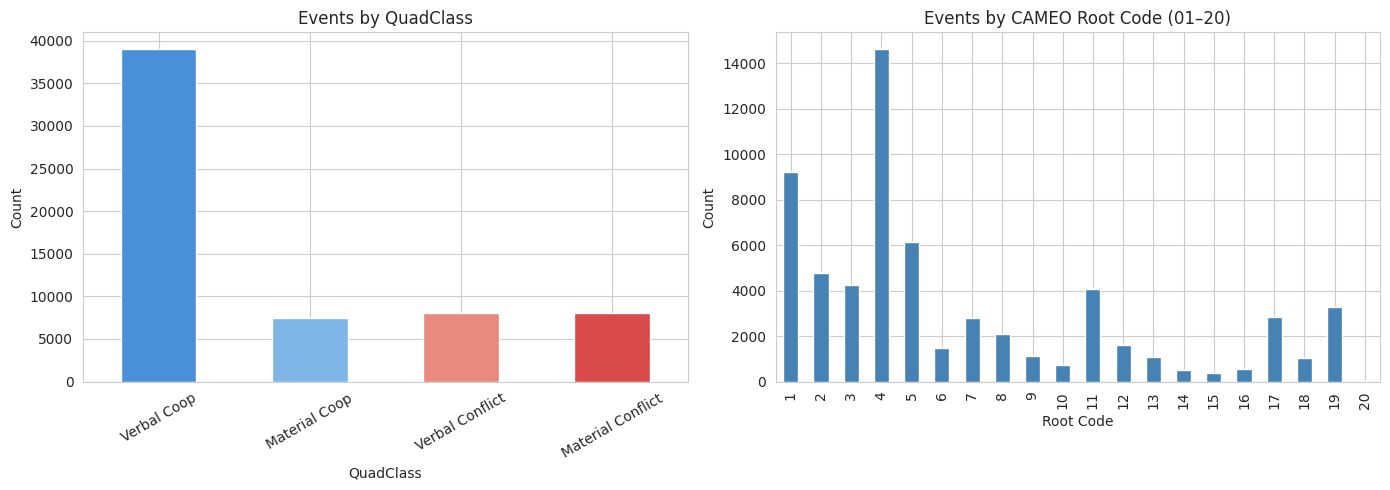

Top 20 countries by material conflict ratio (≥50 events):
QuadClass              total  material_conflict_ratio  any_conflict_ratio
ActionGeo_CountryCode                                                    
CG                       119                    0.605               0.664
CF                       122                    0.451               0.549
MO                        77                    0.390               0.584
TS                        50                    0.340               0.520
SY                       133                    0.301               0.383
NG                        51                    0.294               0.294
RW                       126                    0.254               0.365
GZ                        97                    0.227               0.320
MA                       106                    0.226               0.547
WE                       116                    0.224               0.336
ZI                       167                    0.210 

In [18]:
# QuadClass — your main behavioral axis
quad_labels = {1: 'Verbal Coop', 2: 'Material Coop', 3: 'Verbal Conflict', 4: 'Material Conflict'}
quad_counts = df['QuadClass'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quad_counts.rename(index=quad_labels).plot(
    kind='bar', ax=axes[0], color=['#4a90d9', '#7eb6e8', '#e88b7e', '#d94a4a']
)
axes[0].set_title('Events by QuadClass')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# EventRootCode (CAMEO root codes 01-20)
df['EventRootCode'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Events by CAMEO Root Code (01–20)')
axes[1].set_xlabel('Root Code')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Conflict ratio per country — leading signal for your instability research
country_quad = (
    df.groupby(['ActionGeo_CountryCode', 'QuadClass']).size()
    .unstack(fill_value=0)
)
country_quad['total'] = country_quad.sum(axis=1)
country_quad['material_conflict_ratio'] = country_quad.get(4, 0) / country_quad['total']
country_quad['any_conflict_ratio'] = (country_quad.get(3, 0) + country_quad.get(4, 0)) / country_quad['total']

# Filter to countries with enough data
top_unstable = country_quad[country_quad['total'] >= 50].sort_values(
    'material_conflict_ratio', ascending=False
).head(20)

print("Top 20 countries by material conflict ratio (≥50 events):")
print(top_unstable[['total', 'material_conflict_ratio', 'any_conflict_ratio']].round(3))

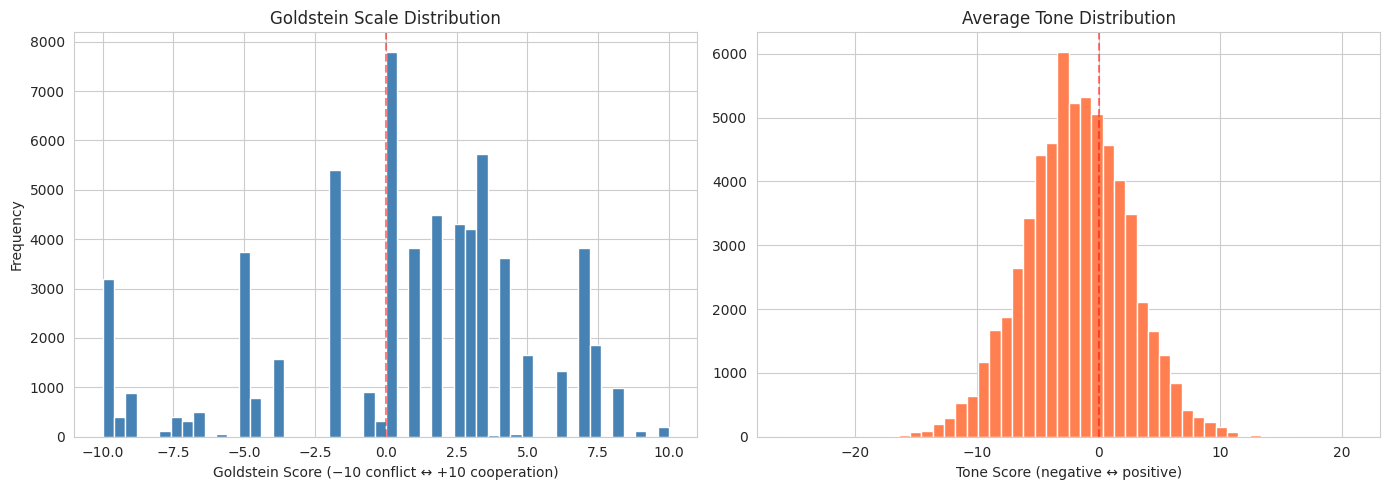

Goldstein–AvgTone correlation: 0.343


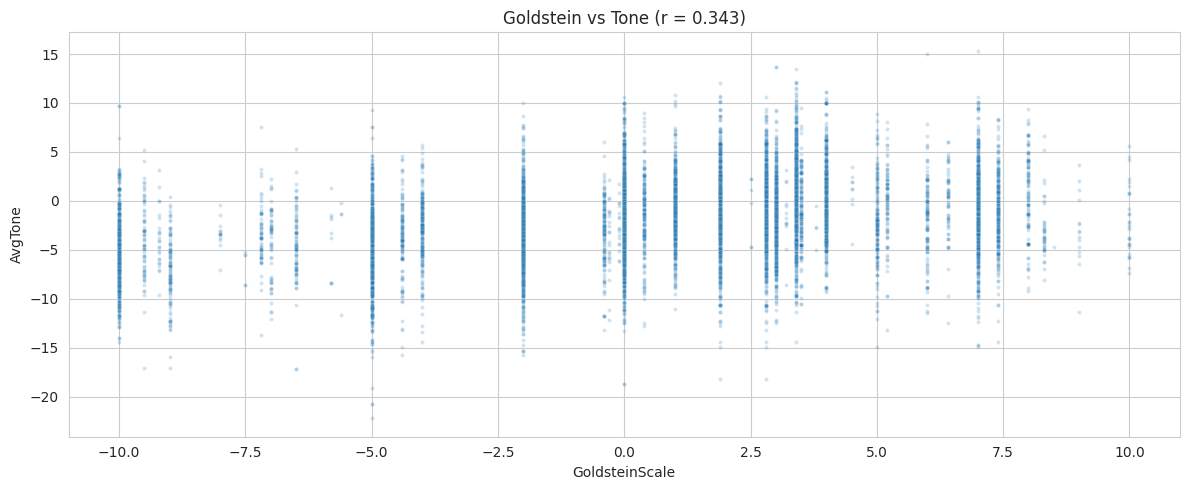

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goldstein distribution
df['GoldsteinScale'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Goldstein Scale Distribution')
axes[0].set_xlabel('Goldstein Score (−10 conflict ↔ +10 cooperation)')
axes[0].set_ylabel('Frequency')

# AvgTone distribution
df['AvgTone'].dropna().hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Average Tone Distribution')
axes[1].set_xlabel('Tone Score (negative ↔ positive)')

plt.tight_layout()
plt.show()

# Relationship: Goldstein vs Tone — are they redundant?
sample = df[['GoldsteinScale', 'AvgTone']].dropna().sample(min(10000, len(df)), random_state=42)
corr = sample.corr().iloc[0, 1]
print(f"Goldstein–AvgTone correlation: {corr:.3f}")
# If correlation is low (<0.3), both carry independent info → use both as features
# If high (>0.7), they're redundant → keep one

sns.scatterplot(data=sample, x='GoldsteinScale', y='AvgTone', alpha=0.2, s=8)
plt.title(f'Goldstein vs Tone (r = {corr:.3f})')
plt.tight_layout()
plt.show()

Top 15 most conflict-prone countries (by mean Goldstein):
                       n_events  goldstein_mean  goldstein_std  tone_mean  \
ActionGeo_CountryCode                                                       
CG                          119           -4.10           5.23      -8.29   
MO                           77           -3.02           5.47      -4.65   
MA                          106           -2.37           5.16      -7.93   
CF                          122           -1.89           5.04      -9.05   
TS                           50           -1.33           5.37      -5.03   
SY                          133           -1.19           5.80      -2.75   
EC                           88           -1.00           5.56      -5.15   
HU                           76           -0.82           4.64      -1.74   
WE                          116           -0.73           5.23      -4.44   
NG                           51           -0.66           5.51      -6.23   
ZI                

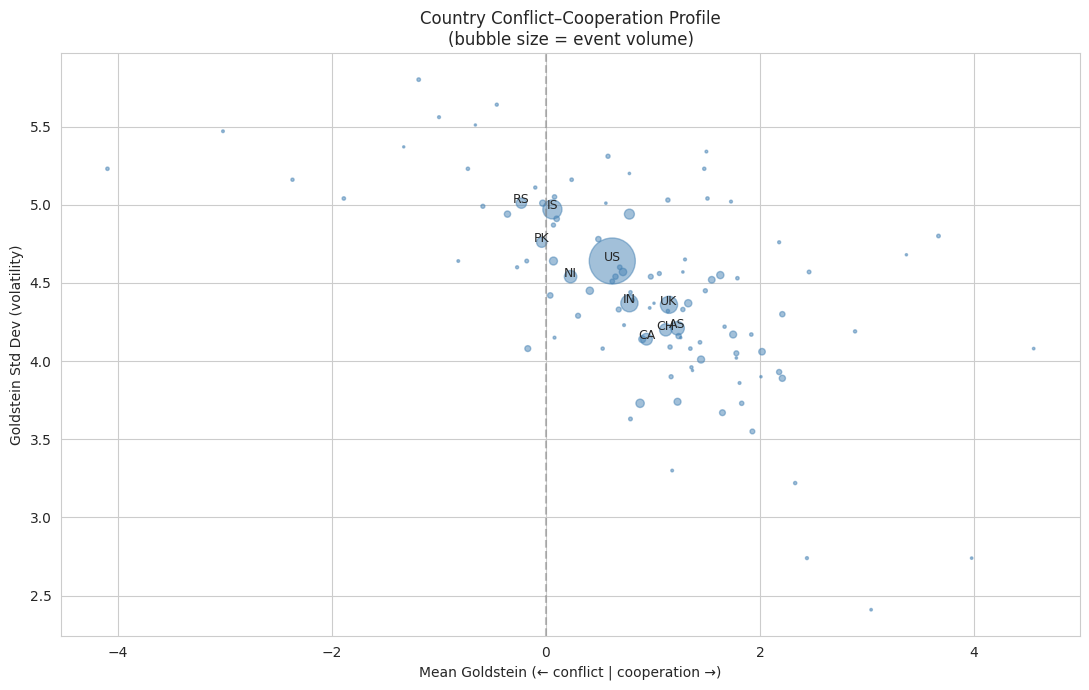

In [20]:
# Mean Goldstein and tone per country (filter to countries with ≥50 events)
country_intensity = df.groupby('ActionGeo_CountryCode').agg(
    n_events=('GLOBALEVENTID', 'size'),
    goldstein_mean=('GoldsteinScale', 'mean'),
    goldstein_std=('GoldsteinScale', 'std'),
    tone_mean=('AvgTone', 'mean'),
    tone_std=('AvgTone', 'std'),
    mentions_mean=('NumMentions', 'mean'),
).query('n_events >= 50').round(2)

# Most conflict-prone countries (lowest Goldstein)
print("Top 15 most conflict-prone countries (by mean Goldstein):")
print(country_intensity.nsmallest(15, 'goldstein_mean'))

print("\nTop 15 most cooperative countries (by mean Goldstein):")
print(country_intensity.nlargest(15, 'goldstein_mean'))

# Visualize — Goldstein mean vs volatility (std)
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(country_intensity['goldstein_mean'], country_intensity['goldstein_std'],
           s=country_intensity['n_events']/20, alpha=0.5, color='steelblue')

# Label notable countries
notable = country_intensity.nlargest(10, 'n_events').index
for country in notable:
    row = country_intensity.loc[country]
    ax.annotate(country, (row['goldstein_mean'], row['goldstein_std']),
                fontsize=9, ha='center')

ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Goldstein (← conflict | cooperation →)')
ax.set_ylabel('Goldstein Std Dev (volatility)')
ax.set_title('Country Conflict–Cooperation Profile\n(bubble size = event volume)')
plt.tight_layout()
plt.show()

In [21]:
# Most active actor countries (who's *doing* things)
actor_counts = df['Actor1CountryCode'].value_counts().head(20)
print("Top 20 most active Actor1 countries:")
print(actor_counts)

# Bilateral patterns — most common country pairs
pairs = df.dropna(subset=['Actor1CountryCode', 'Actor2CountryCode'])
pairs = pairs[pairs['Actor1CountryCode'] != pairs['Actor2CountryCode']]
top_pairs = pairs.groupby(['Actor1CountryCode', 'Actor2CountryCode']).size().nlargest(20)
print("\nTop 20 bilateral interaction pairs:")
print(top_pairs)

Top 20 most active Actor1 countries:
Actor1CountryCode
USA    11274
ISR     1700
GBR     1656
AUS     1046
CHN     1000
PSE      920
RUS      773
CAN      687
NGA      642
IND      618
UKR      585
PAK      585
EUR      527
FRA      471
AFR      422
DEU      402
IRL      396
ITA      372
JPN      363
TUR      318
Name: count, dtype: int64

Top 20 bilateral interaction pairs:
Actor1CountryCode  Actor2CountryCode
ISR                PSE                  367
PSE                ISR                  283
USA                ISR                  211
UKR                RUS                  143
ISR                USA                  138
RUS                UKR                  133
CHN                USA                   91
GBR                USA                   87
USA                CHN                   87
                   PSE                   87
                   GBR                   69
                   MEX                   69
MEX                USA                   62
RUS          

In [22]:
# These are the tables you'll likely cite in your methodology section
country_intensity.to_csv(f'/content/drive/MyDrive/gdelt_data/processed/eda_country_intensity.csv')
country_quad.to_csv(f'/content/drive/MyDrive/gdelt_data/processed/eda_country_quad.csv')

print("Saved EDA outputs to /content/drive/MyDrive/gdelt_data/processed/")

Saved EDA outputs to /content/drive/MyDrive/gdelt_data/processed/


In [24]:
df.describe()

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,...,Actor2Geo_Long,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,DATEADDED,date,date_added,year,month,week
count,6.261100e+04,6.261100e+04,62611.000000,62611.000000,62611.000000,62611.000000,62611.000000,62611.000000,62611.000000,62611.000000,...,43546.000000,62611.000000,62586.000000,62602.000000,6.261100e+04,62611,62611,62611.000000,62611,62611
mean,1.266165e+09,2.025092e+07,202509.155819,2024.991711,2025.733740,0.553465,92.433518,67.747345,6.592021,1.763045,...,-3.071544,2.875357,30.266819,-5.791558,2.025100e+13,2025-09-27 19:14:51.389692160,2025-10-01 00:00:00,2024.991711,2025-09-27 12:23:19.958473984,2025-09-25 19:37:18.220120832
min,1.266119e+09,2.015100e+07,201510.000000,2015.000000,2015.750700,0.000000,10.000000,10.000000,1.000000,1.000000,...,-176.533000,0.000000,-85.622100,-176.533000,2.025100e+13,2015-10-04 00:00:00,2025-10-01 00:00:00,2015.000000,2015-10-01 00:00:00,2015-09-28 00:00:00
25%,1.266139e+09,2.025100e+07,202510.000000,2025.000000,2025.742500,0.000000,36.000000,33.000000,3.000000,1.000000,...,-78.205700,2.000000,25.000000,-80.906600,2.025100e+13,2025-10-01 00:00:00,2025-10-01 00:00:00,2025.000000,2025-10-01 00:00:00,2025-09-29 00:00:00
50%,1.266162e+09,2.025100e+07,202510.000000,2025.000000,2025.742500,1.000000,46.000000,46.000000,4.000000,1.000000,...,7.424250,3.000000,35.685000,2.333330,2.025100e+13,2025-10-01 00:00:00,2025-10-01 00:00:00,2025.000000,2025-10-01 00:00:00,2025-09-29 00:00:00
75%,1.266190e+09,2.025100e+07,202510.000000,2025.000000,2025.742500,1.000000,110.000000,100.000000,10.000000,3.000000,...,46.482500,4.000000,42.149700,46.772800,2.025100e+13,2025-10-01 00:00:00,2025-10-01 00:00:00,2025.000000,2025-10-01 00:00:00,2025-09-29 00:00:00
max,1.266217e+09,2.025100e+07,202510.000000,2025.000000,2025.742500,1.000000,1832.000000,203.000000,20.000000,4.000000,...,178.417000,5.000000,70.065000,179.383000,2.025100e+13,2025-10-01 00:00:00,2025-10-01 00:00:00,2025.000000,2025-10-01 00:00:00,2025-09-29 00:00:00
std,2.889257e+04,1.640290e+03,16.403287,0.164036,0.163992,0.497137,175.279196,53.618101,5.366653,1.100961,...,78.922041,1.240992,21.124816,80.497079,3.870962e+04,NaN,NaN,0.164036,NaN,NaN


In [27]:
print(df.shape)        # (rows, columns)
print(df.head())       # first 5 rows
print(df.dtypes)       # column types
print(df.columns.tolist())  # all column names

(62611, 67)
   GLOBALEVENTID   SQLDATE  MonthYear  Year  FractionDate Actor1Code  \
0     1266118602  20151004     201510  2015     2015.7507     CHRCTH   
1     1266118603  20151004     201510  2015     2015.7507     CHRCTH   
2     1266118604  20151004     201510  2015     2015.7507        JUD   
3     1266118605  20151004     201510  2015     2015.7507        JUD   
4     1266118606  20151004     201510  2015     2015.7507        JUD   

  Actor1Name Actor1CountryCode Actor1KnownGroupCode Actor1EthnicCode  ...  \
0   CATHOLIC              None                 None             None  ...   
1   CATHOLIC              None                 None             None  ...   
2     LAWYER              None                 None             None  ...   
3     LAWYER              None                 None             None  ...   
4     LAWYER              None                 None             None  ...   

  ActionGeo_Long ActionGeo_FeatureID       DATEADDED  \
0        8.51667            -2002531

feature engineering

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Install HDBSCAN if needed
try:
    import hdbscan
except ImportError:
    !pip install hdbscan -q
    import hdbscan

CLEAN_PATH = '/content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet'
PROCESSED_DIR = '/content/drive/MyDrive/gdelt_data/processed'

df = pd.read_parquet(CLEAN_PATH)
print(f"Loaded {len(df):,} events")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

In [ ]:
TIME_BUCKET = 'month'  # change to 'week' if you want finer granularity
MIN_EVENTS_PER_BUCKET = 5  # drop rows with too few events to characterize

# Group key
df['country'] = df['ActionGeo_CountryCode']
df['period'] = df[TIME_BUCKET]

# ---- Core aggregate features ----
agg = df.groupby(['country', 'period']).agg(
    n_events=('GLOBALEVENTID', 'size'),
    goldstein_mean=('GoldsteinScale', 'mean'),
    goldstein_std=('GoldsteinScale', 'std'),
    goldstein_min=('GoldsteinScale', 'min'),  # worst event in period
    tone_mean=('AvgTone', 'mean'),
    tone_std=('AvgTone', 'std'),
    mentions_sum=('NumMentions', 'sum'),
    mentions_mean=('NumMentions', 'mean'),
    sources_mean=('NumSources', 'mean'),
    n_unique_actor1=('Actor1CountryCode', 'nunique'),
    n_unique_actor2=('Actor2CountryCode', 'nunique'),
).reset_index()

# ---- QuadClass breakdown (the behavioral signal) ----
quad = (df.groupby(['country', 'period', 'QuadClass']).size()
          .unstack(fill_value=0)
          .reset_index())
quad.columns = ['country', 'period'] + [f'quad_{int(c)}_count' for c in quad.columns[2:]]

# Make sure all 4 QuadClass columns exist (some periods may not have all types)
for q in [1, 2, 3, 4]:
    col = f'quad_{q}_count'
    if col not in quad.columns:
        quad[col] = 0

# ---- Merge ----
panel = agg.merge(quad, on=['country', 'period'], how='left')

# ---- Derived ratios (per-row normalized features) ----
panel['verbal_coop_ratio']      = panel['quad_1_count'] / panel['n_events']
panel['material_coop_ratio']    = panel['quad_2_count'] / panel['n_events']
panel['verbal_conflict_ratio']  = panel['quad_3_count'] / panel['n_events']
panel['material_conflict_ratio']= panel['quad_4_count'] / panel['n_events']
panel['any_conflict_ratio']     = (panel['quad_3_count'] + panel['quad_4_count']) / panel['n_events']

# ---- Filter: drop rows with too few events to be meaningful ----
n_before = len(panel)
panel = panel[panel['n_events'] >= MIN_EVENTS_PER_BUCKET].reset_index(drop=True)
print(f"Panel rows: {n_before:,} → {len(panel):,} (after min_events filter)")
print(f"Unique countries: {panel['country'].nunique()}")
print(f"Unique periods:   {panel['period'].nunique()}")

# Fill std NaNs (occur when n_events=1; we've filtered these out but be safe)
panel['goldstein_std'] = panel['goldstein_std'].fillna(0)
panel['tone_std']      = panel['tone_std'].fillna(0)

# Save
panel.to_parquet(f'{PROCESSED_DIR}/panel_country_{TIME_BUCKET}.parquet', index=False)
print(f"\nSaved panel to {PROCESSED_DIR}/panel_country_{TIME_BUCKET}.parquet")
panel.head()

In [ ]:
# Feature columns to actually feed into clustering
# (excludes raw counts that are dominated by country size; uses ratios + intensity)
FEATURE_COLS = [
    'n_events',           # absolute activity level — log transform below
    'goldstein_mean',     # average conflict-cooperation
    'goldstein_std',      # volatility
    'goldstein_min',      # worst event
    'tone_mean',
    'tone_std',
    'mentions_mean',
    'n_unique_actor1',    # actor diversity
    'verbal_coop_ratio',
    'material_coop_ratio',
    'verbal_conflict_ratio',
    'material_conflict_ratio',
]

X_raw = panel[FEATURE_COLS].copy()

# Log-transform count features (highly skewed — US has 100× more events than small countries)
for col in ['n_events', 'mentions_mean', 'n_unique_actor1']:
    X_raw[col] = np.log1p(X_raw[col])

# Standardize (mean=0, std=1) — essential for both K-Means and HDBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {FEATURE_COLS}")

# Optional: PCA for visualization and noise reduction
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)
print(f"After PCA: {X_pca.shape} (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

Clustering